In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\drish\Documents\Projects\loan-eligibility-predictor\data\train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\drish\Documents\Projects\loan-eligibility-predictor\data\train.csv")

df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [4]:
# Shape of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 614
Columns: 13


In [5]:
# Column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
missing = df.isnull().sum()

missing[missing > 0]

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

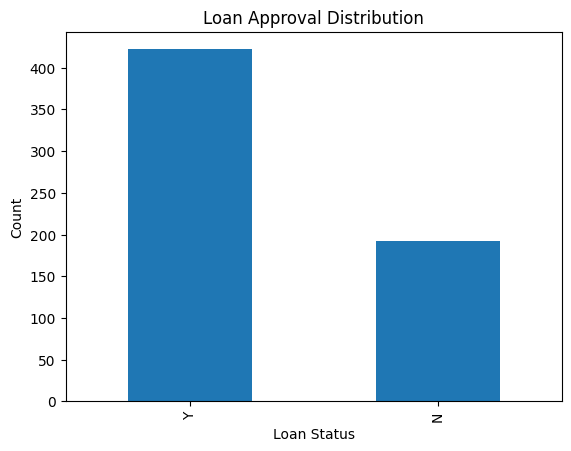

In [9]:
import matplotlib.pyplot as plt

df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

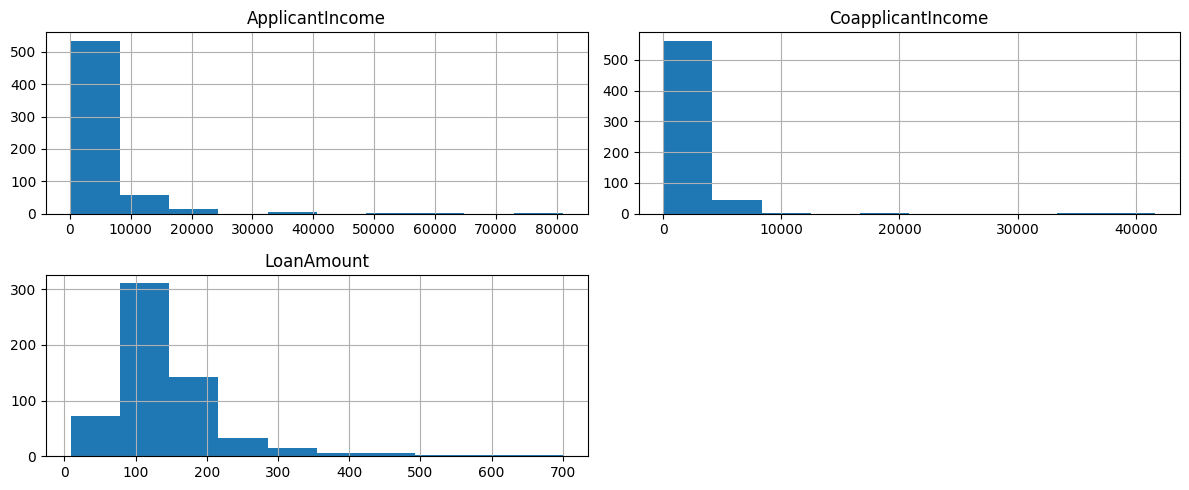

In [10]:
numeric_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

df[numeric_cols].hist(figsize=(12,5))

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

pd.crosstab(
    df["Credit_History"],
    df["Loan_Status"]
)

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,97,378


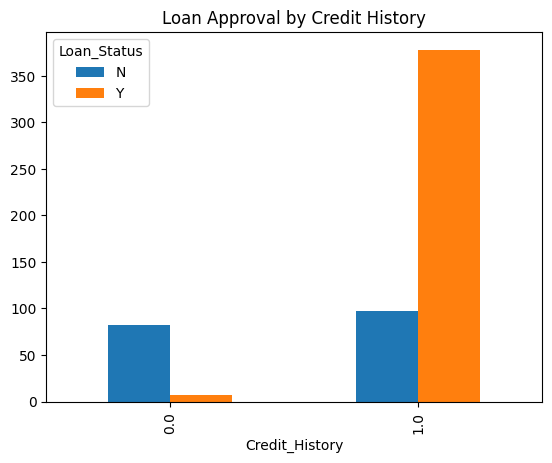

In [12]:
pd.crosstab(
    df["Credit_History"],
    df["Loan_Status"]
).plot(kind="bar")

plt.title("Loan Approval by Credit History")

plt.show()

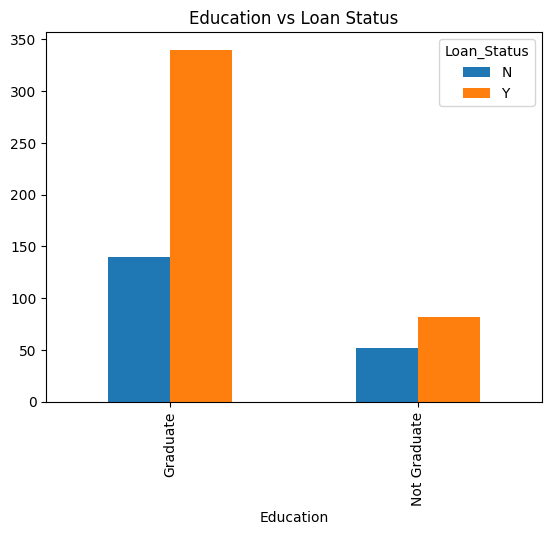

In [13]:
pd.crosstab(
    df["Education"],
    df["Loan_Status"]
).plot(kind="bar")

plt.title("Education vs Loan Status")

plt.show()

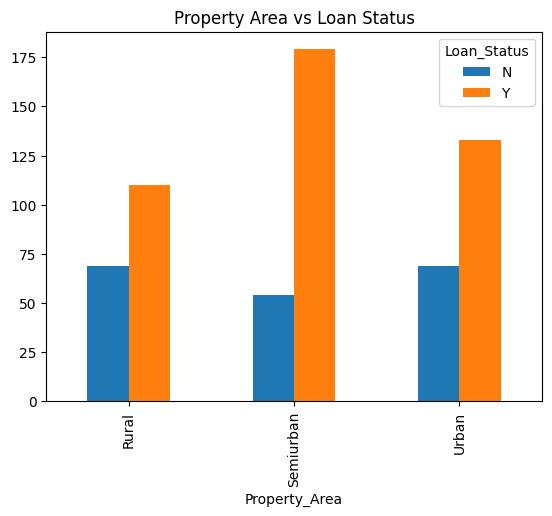

In [14]:
pd.crosstab(
    df["Property_Area"],
    df["Loan_Status"]
).plot(kind="bar")

plt.title("Property Area vs Loan Status")

plt.show()

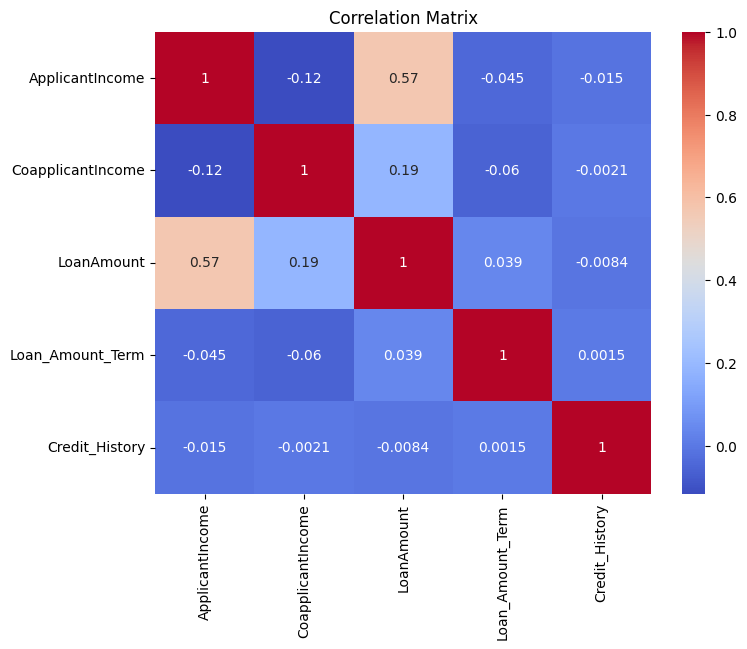

In [15]:
import seaborn as sns

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [16]:
# Make a copy
loan_df = df.copy()

loan_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [17]:
loan_df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [18]:
categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for col in categorical_cols:
    loan_df[col].fillna(loan_df[col].mode()[0], inplace=True)

C:\Users\drish\AppData\Local\Temp\ipykernel_2784\202211025.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_df[col].fillna(loan_df[col].mode()[0], inplace=True)


In [19]:
loan_df["LoanAmount"].fillna(
    loan_df["LoanAmount"].median(),
    inplace=True
)

loan_df["Loan_Amount_Term"].fillna(
    loan_df["Loan_Amount_Term"].median(),
    inplace=True)

loan_df["Credit_History"].fillna(
    loan_df["Credit_History"].mode()[0],
    inplace=True)

C:\Users\drish\AppData\Local\Temp\ipykernel_2784\2419832863.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_df["LoanAmount"].fillna(
C:\Users\drish\AppData\Local\Temp\ipykernel_2784\2419832863.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[

In [20]:
loan_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [21]:
loan_df.drop("Loan_ID", axis=1, inplace=True)

In [22]:
loan_df["TotalIncome"] = (
    loan_df["ApplicantIncome"] +
    loan_df["CoapplicantIncome"]
)

In [23]:
import numpy as np

loan_df["LogIncome"] = np.log1p(
    loan_df["TotalIncome"]
)

In [24]:
loan_df["LogLoanAmount"] = np.log1p(
    loan_df["LoanAmount"]
)

In [25]:
loan_df["EMI"] = (
    loan_df["LoanAmount"] /
    loan_df["Loan_Amount_Term"]
)

In [26]:
loan_df["LoanToIncomeRatio"] = (
    loan_df["LoanAmount"] /
    loan_df["TotalIncome"]
)

In [27]:
loan_df["Dependents"] = loan_df["Dependents"].replace("3+", 3)
loan_df["Dependents"] = loan_df["Dependents"].astype(int)

loan_df["IncomePerDependent"] = (
    loan_df["TotalIncome"] /
    (loan_df["Dependents"] + 1)
)

In [28]:
loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LogIncome,LogLoanAmount,EMI,LoanToIncomeRatio,IncomePerDependent
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,8.674197,4.859812,0.355556,0.021884,5849.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,8.714732,4.859812,0.355556,0.021015,3045.5
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,8.006701,4.204693,0.183333,0.022000,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,8.505525,4.795791,0.333333,0.024287,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,8.699681,4.955827,0.391667,0.023500,6000.0


In [29]:
loan_df = pd.get_dummies(
    loan_df,
    drop_first=True
)

In [30]:
loan_df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,LogIncome,LogLoanAmount,EMI,LoanToIncomeRatio,IncomePerDependent,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,0,5849,0.0,128.0,360.0,1.0,5849.0,8.674197,4.859812,0.355556,0.021884,5849.0,True,False,False,False,False,True,True
1,1,4583,1508.0,128.0,360.0,1.0,6091.0,8.714732,4.859812,0.355556,0.021015,3045.5,True,True,False,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,3000.0,8.006701,4.204693,0.183333,0.022000,3000.0,True,True,False,True,False,True,True
3,0,2583,2358.0,120.0,360.0,1.0,4941.0,8.505525,4.795791,0.333333,0.024287,4941.0,True,True,True,False,False,True,True
4,0,6000,0.0,141.0,360.0,1.0,6000.0,8.699681,4.955827,0.391667,0.023500,6000.0,True,False,False,False,False,True,True


In [31]:
X = loan_df.drop("Loan_Status_Y", axis=1)

y = loan_df["Loan_Status_Y"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
print(X_train.shape)
print(X_test.shape)

(491, 18)
(123, 18)


In [34]:
loan_df.to_csv(
    "../data/processed_loan_data.csv",
    index=False
)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

In [39]:
print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))
print("ROC AUC  :", roc_auc_score(y_test, log_pred))

Accuracy : 0.8699186991869918
Precision: 0.8484848484848485
Recall   : 0.9882352941176471
F1 Score : 0.9130434782608695
ROC AUC  : 0.796749226006192


In [40]:
DecisionTreeClassifier
RandomForestClassifier

sklearn.ensemble._forest.RandomForestClassifier

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Dependents','ApplicantIncome','CoapplicantIncome',..., 'Self_Employed_Yes','Property_Area_Semiurban','Property_Area_Urban']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [42]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [44]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, rf_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.878049,0.888889,0.941176,0.914286
0,Logistic Regression,0.869919,0.848485,0.988235,0.913043
1,Decision Tree,0.723577,0.822785,0.764706,0.792683


In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance.head(10)

,Feature,Importance
5,Credit_History,0.215097
10,LoanToIncomeRatio,0.088521
1,ApplicantIncome,0.085787
11,IncomePerDependent,0.080114
7,LogIncome,0.079076
6,TotalIncome,0.078318
9,EMI,0.074327
8,LogLoanAmount,0.062483
3,LoanAmount,0.061039
2,CoapplicantIncome,0.052558


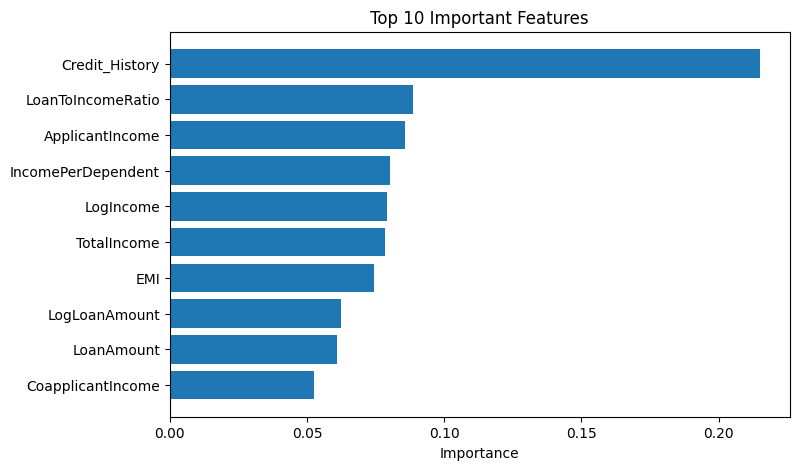

In [46]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

In [47]:
import os
import joblib

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(
    X.columns.tolist(),
    "../artifacts/feature_columns.pkl"
)

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [48]:
loan_df.columns

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'LogIncome',
       'LogLoanAmount', 'EMI', 'LoanToIncomeRatio', 'IncomePerDependent',
       'Gender_Male', 'Married_Yes', 'Education_Not Graduate',
       'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban',
       'Loan_Status_Y'],
      dtype='object')

In [49]:
loan_df.columns.tolist()

['Dependents',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'TotalIncome',
 'LogIncome',
 'LogLoanAmount',
 'EMI',
 'LoanToIncomeRatio',
 'IncomePerDependent',
 'Gender_Male',
 'Married_Yes',
 'Education_Not Graduate',
 'Self_Employed_Yes',
 'Property_Area_Semiurban',
 'Property_Area_Urban',
 'Loan_Status_Y']

In [52]:
type(rf_model)

sklearn.ensemble._forest.RandomForestClassifier

In [53]:
import joblib
import os

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(rf_model, "../artifacts/model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [54]:
import os

print(os.path.getsize("../artifacts/model.pkl"))

2769385


In [55]:
model = joblib.load("../artifacts/model.pkl")
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
